<a href="https://colab.research.google.com/github/Redcoder815/Machine_learning_phitron/blob/main/29MultipleLinearRegressionPracticeProblem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [2]:
X = np.array([
    [1,4, 1.5, 3.8],
    [3,6, 1.0, 3.1],
    [4,7, 0.8, 3.9],
    [5,8, 0.4, 3.4],
    [7,9, 0.2, 2.8]
])

# w =[5,10,-2,0.5] , b=2.0
y = np.array([45.9 ,  76.55,  92.35, 107.9 , 128. ])

In [3]:
def make_prediction(X, W, b):
  m = X.shape[0]
  pred_list = np.zeros((m,))

  for i in  range(m):
    pred_list[i] = np.dot(W,X[i]) + b

  return pred_list

In [4]:
m = X.shape[0]
n = X.shape[1]

W_init = np.ones((n,))
b_init = 1.0

make_prediction(X, W_init, b_init)

array([11.3, 14.1, 16.7, 17.8, 20. ])

In [5]:
def compute_cost(X, y, W, b):
  m = X.shape[0]
  cost = 0.0

  pred_list = make_prediction(X, W, b)
  # print(pred_list)

  error = pred_list - y
  # print(error)

  error_squared = error ** 2
  cost = np.sum(error_squared)

  cost = cost / (2*m)

  return cost

In [6]:
W_init = np.ones((n,))
b_init = 1.0
compute_cost(X,y, W_init ,b_init)

np.float64(3060.2095)

In [7]:
def calculate_gradient(X, y, W, b):
  m = X.shape[0]
  n = X.shape[1]

  dj_dw = np.zeros((n,))
  dj_db = 0.0

  for i in range(m):
    prediction = np.dot(W, X[i]) + b
    # print(f"prediction: {prediction}")
    error = prediction - y[i]
    # print(f'error: {error}')

    dj_db = dj_db + error
    # print(f'dj_db: {dj_db}')

    for j in range(n):
      dj_dw[j] = dj_dw[j] + (error * X[i, j])
      # print(f'dj_dw{i, j}: {dj_dw}')

  return dj_dw / m, dj_db /m

In [8]:
W_init = np.ones((n,))
b_init = 1.0
calculate_gradient(X,y, W_init ,b_init)

(array([-346.21 , -547.09 ,  -46.502, -245.77 ]), np.float64(-74.16))

In [9]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
  """Automates the tuning of w and b to minimize cost"""
  w = w_input
  b = b_input
  cost_memo = []
  iteration = []

  for i in range(max_iter):
    # 1. Calculate the gradients (the slope)
    dj_dw, dj_db = calculate_gradient(X, y, w, b)

    # 2. Update parameters by taking a small step (alpha) against the gradient

    w = w - alpha * dj_dw
    b = b - alpha * dj_db



    # 3. Track progress by saving the cost
    cost = compute_cost(X,y, w, b)
    cost_memo.append(cost)
    iteration.append(i)

    # Log the status every 100 steps
    if i % 100 == 0:
      print(f"Iteration {i}: Cost {cost:0.4f},dj_dw: {dj_dw} ,dj_db : {dj_db} w: {w}, b: {b:0.4f}")

  return w, b, cost_memo, iteration

In [10]:
W_init = np.zeros((n,))
b_init = 0.0

w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, w_input=W_init, b_input=b_init, max_iter=10000, alpha=0.01)

Iteration 0: Cost 188.4458,dj_dw: [-416.09  -660.91   -57.608 -299.43 ] ,dj_db : -90.14 w: [4.1609  6.6091  0.57608 2.9943 ], b: 0.9014
Iteration 100: Cost 0.1977,dj_dw: [-0.28972633 -0.05290958  0.24653403  0.43027154] ,dj_db : 0.08612436152810546 w: [ 6.8215041   8.3071171  -0.38008643  1.775159  ], b: 0.7104
Iteration 200: Cost 0.1303,dj_dw: [ 0.02982799 -0.05138487  0.04097921  0.06083368] ,dj_db : 0.007027042739051126 w: [ 6.88604616  8.35924356 -0.48209566  1.60468101], b: 0.6799
Iteration 300: Cost 0.1229,dj_dw: [ 0.05097646 -0.04994653  0.0258774   0.03389236] ,dj_db : 0.001434162447482379 w: [ 6.84103994  8.40989801 -0.51257454  1.56262078], b: 0.6769
Iteration 400: Cost 0.1162,dj_dw: [ 0.05111217 -0.04855146  0.02422668  0.0311383 ] ,dj_db : 0.0010265453320016603 w: [ 6.7896808   8.45913669 -0.53741432  1.53048588], b: 0.6757
Iteration 500: Cost 0.1098,dj_dw: [ 0.04980317 -0.04719556  0.0235398   0.03011513] ,dj_db : 0.0009845325017138861 w: [ 6.7392106   8.50700022 -0.561278

Q1. Feature & Target বিশ্লেষণ করো Kaggle এর Salary Prediction Dataset লোড করো। Years of Experience , Age, Education Level — এই তিনটি feature এবং Salary target এর মধ্যে relationship বোঝার জন্য:

প্রতিটি feature এর বিপরীতে Salary এর scatter plot আঁকো

correlation matrix বের করো

কোন feature টি সবচেয়ে strongly linear সেটা লিখে জানাও


In [11]:
import pandas as pd

In [12]:
df = pd.read_csv('/content/Salary Data.csv')
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [13]:
df.dropna(subset = ['Education Level'], inplace = True)

In [14]:
df['Education Level'].unique()

array(["Bachelor's", "Master's", 'PhD'], dtype=object)

In [15]:
from sklearn.preprocessing import OrdinalEncoder

eduacation_level_encoder = OrdinalEncoder(categories=[["Bachelor's", "Master's", 'PhD']])

eduacation_level_encoder.fit(df[['Education Level']])

df['encoded_education_level'] = eduacation_level_encoder.transform(df[['Education Level']]).ravel()

In [16]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,encoded_education_level
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,0.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0,1.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0,2.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,0.0
4,52.0,Male,Master's,Director,20.0,200000.0,1.0
...,...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0,0.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0,1.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0,0.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0,0.0


In [17]:
features = ['Years of Experience', 'Age', 'encoded_education_level']
target = 'Salary'

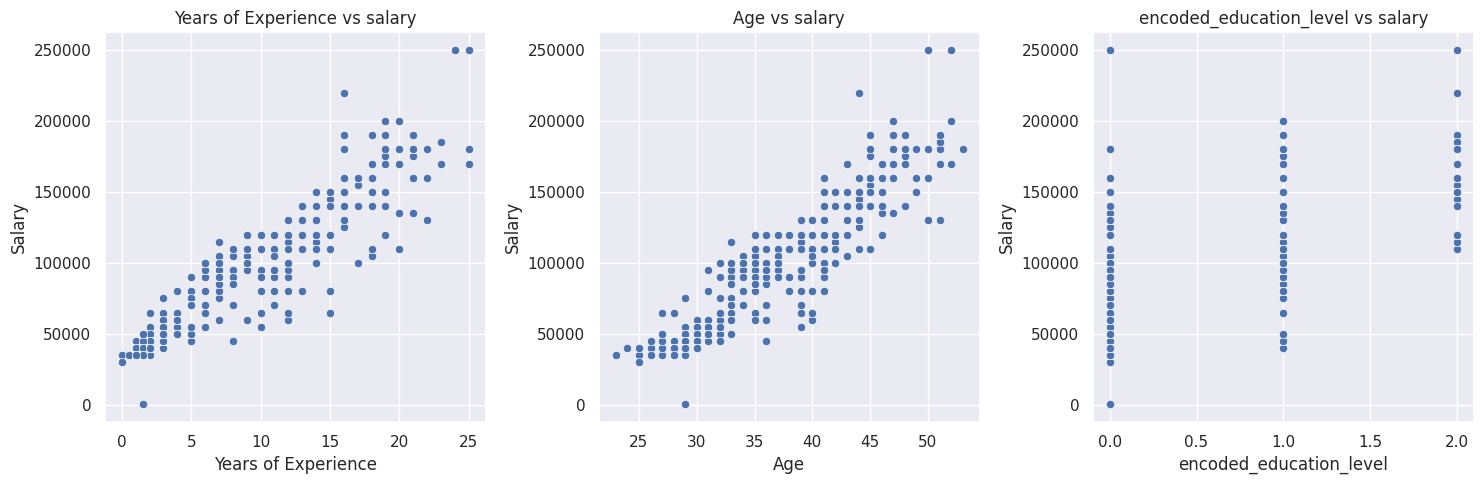

In [18]:
plt.figure(figsize = (15, 5))

for i, feature in enumerate(features):
  plt.subplot(1, 3, i+1)
  sns.scatterplot(data = df, x = feature, y = target)
  plt.title(f'{feature} vs salary')
  plt.xlabel(feature)
  plt.ylabel('Salary')
plt.tight_layout()
plt.show()

In [19]:
numerical_cols = ['Years of Experience', 'Age', 'encoded_education_level', 'Salary']
correlation_matrix = df[numerical_cols].corr()

print(correlation_matrix)

                         Years of Experience       Age  \
Years of Experience                 1.000000  0.979128   
Age                                 0.979128  1.000000   
encoded_education_level             0.590863  0.562693   
Salary                              0.930338  0.922335   

                         encoded_education_level    Salary  
Years of Experience                     0.590863  0.930338  
Age                                     0.562693  0.922335  
encoded_education_level                 1.000000  0.670371  
Salary                                  0.670371  1.000000  


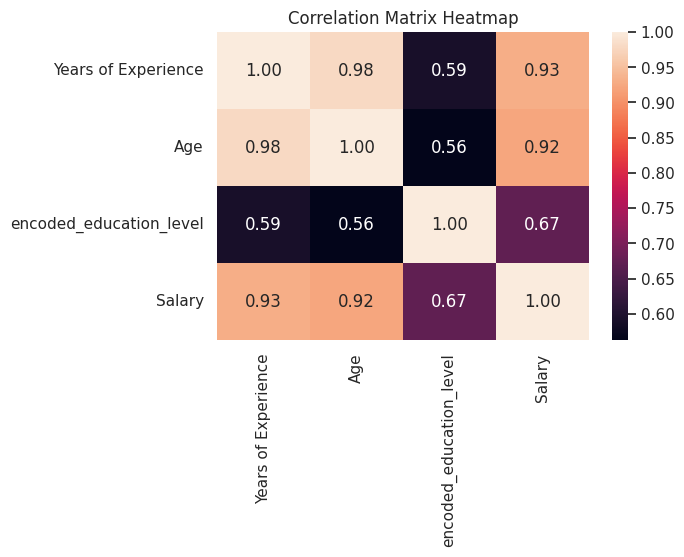

In [20]:
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

Years of experience and Age column strongly linear

Q2. NumPy দিয়ে Prediction Function লেখো নিচের data manually define করো (অন্তত ১০টি row, ৩টি feature):

Feature: study_hours, sleep_hours, attendance_pct → Target: exam_score
NumPy ব্যবহার করে:

predict(X, w, b) function লেখো যেখানে y_pred = X @ w + b

Random weights দিয়ে সব rows এর prediction করো এবং actual values এর সাথে পাশাপাশি print করো


In [21]:
X = np.array([
    [5.0, 7.5, 85.0],
    [3.2, 6.0, 70.0],
    [7.5, 8.0, 95.0],
    [1.5, 5.5, 60.0],
    [6.0, 7.0, 90.0],
    [4.5, 6.5, 78.0],
    [2.0, 8.0, 65.0],
    [8.0, 7.5, 98.0],
    [5.5, 6.0, 82.0],
    [4.0, 7.0, 75.0]
])

y_actual = np.array([78, 62, 93, 45, 85, 74, 55, 97, 80, 70])

In [22]:
np.random.seed(42)
W = np.random.randn(3)
b = np.random.randn()

In [23]:
predicted_value = make_prediction(X, W, b)

In [24]:
for actual, pred in  zip(y_actual, predicted_value):
  print(f'Actual value: {actual}, Predicted value: {pred}')

Actual value: 78, Predicted value: 58.02314410123916
Actual value: 62, Predicted value: 47.621127006065336
Actual value: 93, Predicted value: 65.67268271418858
Actual value: 45, Predicted value: 40.36895971552491
Actual value: 85, Predicted value: 61.82743309533945
Actual value: 74, Predicted value: 53.37923155919989
Actual value: 55, Predicted value: 43.51009872960603
Actual value: 97, Predicted value: 67.93323755558187
Actual value: 80, Predicted value: 56.535832015199475
Actual value: 70, Predicted value: 51.1186767178066


Q3. Scikit-learn দিয়ে প্রথম Multiple Linear Regression (MLR) Model sklearn.datasets.fetch_california_housing() লোড করো।

MedInc, AveRooms, HouseAge — শুধু এই ৩টি feature নাও

LinearRegression দিয়ে model train করো

coef_ এবং intercept_ print করো

যেকোনো ৫টি sample এর predicted vs actual value দেখাও


In [25]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression

In [26]:
california = fetch_california_housing(as_frame=True)
df = california.frame
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [27]:
features = ['MedInc', 'AveRooms', 'HouseAge']
X = df[features]
y = df['MedHouseVal']

In [28]:
model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [29]:
print(f'coeficient: {model.coef_}')
print(f'intercept: {model.intercept_}')

coeficient: [ 0.4427634  -0.02715343  0.01682208]
intercept: 0.020406956964582168


In [30]:
X_test = X.head(5)
y_actual = y.head(5).values

In [31]:
y_predict = model.predict(X_test)

for actual, pred in zip(y_actual, y_predict):
  print(f'Actual: {actual}, prediction {pred}')

Actual: 4.526, prediction 4.206563077164015
Actual: 3.585, prediction 3.8798398883248844
Actual: 3.521, prediction 3.88341489382408
Actual: 3.413, prediction 3.235752205438251
Actual: 3.422, prediction 2.427537839153152


Q4. MSE Cost Function implement ও visualize করো Q2 এর data ব্যবহার করো।

NumPy দিয়ে MSE cost function লেখো: J = (1/2m) * sum((y_pred - y)^2)

w[0] কে -10 থেকে +10 এর মধ্যে vary করো, বাকি weights fixed রাখো

Cost এর change একটি line plot এ দেখাও এবং minimum কোথায় সেটা mark করো


In [32]:
X = np.array([
    [5.0, 7.5, 85.0], [3.2, 6.0, 70.0], [7.5, 8.0, 95.0],
    [1.5, 5.5, 60.0], [6.0, 7.0, 90.0], [4.5, 6.5, 78.0],
    [2.0, 8.0, 65.0], [8.0, 7.5, 98.0], [5.5, 6.0, 82.0],
    [4.0, 7.0, 75.0]
])
y = np.array([85, 65, 92, 50, 88, 75, 58, 96, 78, 70])

In [33]:
w_fixed = np.array([0.5, 0.2, 0.1])
b_fixed = 0.5

w0_vals = np.linspace(-10, 10, 100)
costs = []

In [34]:
for w0 in w0_vals:
    w_current = w_fixed.copy()
    w_current[0] = w0 # w[0] পরিবর্তন করা হচ্ছে
    cost = compute_cost(X, y, w_current, b_fixed)
    costs.append(cost)

costs = np.array(costs)

In [35]:
min_idx = np.argmin(costs)
best_w0 = w0_vals[min_idx]
min_cost = costs[min_idx]

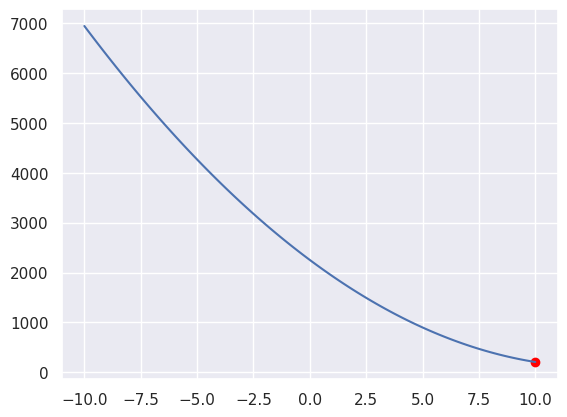

In [36]:
plt.plot(w0_vals, costs)
plt.scatter(best_w0, min_cost, color = 'red')
plt.show()

In [37]:
url = "https://raw.githubusercontent.com/justmarkham/scikit-learn-videos/master/data/Advertising.csv"
df = pd.read_csv(url, index_col=0)
df

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


In [38]:
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [39]:
X = df[['TV', 'Radio', 'Newspaper']].values
y = df['Sales'].values

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Display the first few rows of the scaled features to verify
print("Scaled X (first 5 rows):")
print(X_scaled[:5])

Scaled X (first 5 rows):
[[ 0.96985227  0.98152247  1.77894547]
 [-1.19737623  1.08280781  0.66957876]
 [-1.51615499  1.52846331  1.78354865]
 [ 0.05204968  1.21785493  1.28640506]
 [ 0.3941822  -0.84161366  1.28180188]]


In [41]:
n = X_scaled.shape[1]
W_init = np.zeros((n,))
b_init = 0.0

In [42]:
w_final, b_final, cost_memo, iter_list = gradient_descent(X_scaled, y, w_input=W_init, b_input=b_init, max_iter=1000, alpha=0.01)

Iteration 0: Cost 109.6334,dj_dw: [-4.07100612 -2.9988908  -1.18815867] ,dj_db : -14.022500000000003 w: [0.04071006 0.02998891 0.01188159], b: 0.1402
Iteration 100: Cost 15.7476,dj_dw: [-1.42232363 -0.94193715  0.00849317] ,dj_db : -5.13268850550386 w: [2.54182891 1.77635654 0.42770435], b: 8.9411
Iteration 200: Cost 3.3457,dj_dw: [-0.50625347 -0.34425966  0.15405   ] ,dj_db : -1.8787299906957775 w: [3.42287994 2.35944301 0.3127875 ], b: 12.1626
Iteration 300: Cost 1.6663,dj_dw: [-0.18272475 -0.14615512  0.11491833] ,dj_db : -0.6876759371146081 w: [3.73843171 2.58714537 0.17465678], b: 13.3417
Iteration 400: Cost 1.4324,dj_dw: [-0.06663474 -0.06919131  0.06752374] ,dj_db : -0.25171163329932383 w: [3.85285142 2.68897003 0.08485972], b: 13.7733
Iteration 500: Cost 1.3985,dj_dw: [-0.02448568 -0.0348403   0.03672916] ,dj_db : -0.092134598462257 w: [3.89471947 2.73868989 0.03424984], b: 13.9313
Iteration 600: Cost 1.3932,dj_dw: [-0.00904969 -0.01806051  0.01939721] ,dj_db : -0.0337242427874

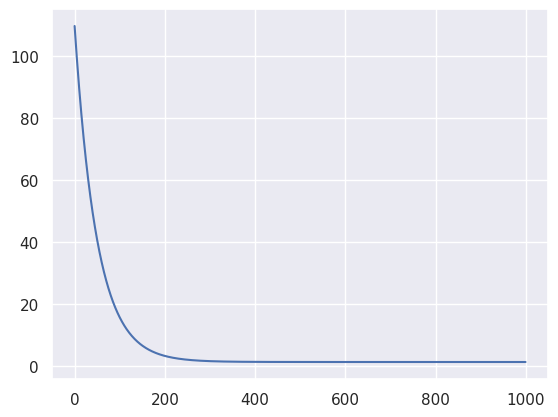

In [43]:
plt.plot(iter_list, cost_memo)
plt.show()

Q6. LinearRegression vs SGDRegressor তুলনা Energy Efficiency dataset (UCI) থেকে heating load predict করো।

LinearRegression এবং SGDRegressor দুটোই একই data তে train করো

দুটোর learned weights ও MSE পাশাপাশি একটি table এ দেখাও

২-৩ লাইনে লেখো কেন SGDRegressor এর weights exact match করে না

Covers: Scikit-learn SGDRegressor, why results differ


In [44]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [45]:
df = pd.read_excel('/content/ENB2012_data.xlsx')
df

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
...,...,...,...,...,...,...,...,...,...,...
763,0.64,784.0,343.0,220.50,3.5,5,0.4,5,17.88,21.40
764,0.62,808.5,367.5,220.50,3.5,2,0.4,5,16.54,16.88
765,0.62,808.5,367.5,220.50,3.5,3,0.4,5,16.44,17.11
766,0.62,808.5,367.5,220.50,3.5,4,0.4,5,16.48,16.61


In [46]:
X = df[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']].values
y = df['Y1'].values

In [47]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [48]:
lr = LinearRegression()
lr.fit(X_scaled, y)
y_pred_lr = lr.predict(X_scaled)

In [49]:
sgd = SGDRegressor(max_iter=5000, tol=1e-4, random_state=42)
sgd.fit(X_scaled, y)
y_pred_sgd = sgd.predict(X_scaled)

In [50]:
mse_lr = mean_squared_error(y, y_pred_lr)
mse_sgd = mean_squared_error(y, y_pred_sgd)

In [51]:
weights_data = {
    'LinearRegression': list(lr.coef_) + [lr.intercept_, mse_lr],
    'SGDRegressor': list(sgd.coef_) + [sgd.intercept_[0], mse_sgd]
}

In [52]:
df_comparison = pd.DataFrame(weights_data)
df_comparison

,LinearRegression,SGDRegressor
0,-6.847108,-3.483826
1,-3.766967,-1.390698
2,0.711360,1.240828
3,-4.016872,-1.955390
4,7.297419,8.378725
5,-0.026084,-0.021415
6,2.653721,2.659869
7,0.315844,0.318149
8,22.307195,22.302151
9,8.520534,8.629248


In [53]:
weights_data = {
    'Parameter': [f'Weight (X{i})' for i in range(1, 9)] + ['Intercept (Bias)', 'Model MSE'],
    'LinearRegression': list(lr.coef_) + [lr.intercept_, mse_lr],
    'SGDRegressor': list(sgd.coef_) + [sgd.intercept_[0], mse_sgd]
}

In [54]:
df_comparison = pd.DataFrame(weights_data)
df_comparison

,Parameter,LinearRegression,SGDRegressor
0,Weight (X1),-6.847108,-3.483826
1,Weight (X2),-3.766967,-1.390698
2,Weight (X3),0.711360,1.240828
3,Weight (X4),-4.016872,-1.955390
4,Weight (X5),7.297419,8.378725
5,Weight (X6),-0.026084,-0.021415
6,Weight (X7),2.653721,2.659869
7,Weight (X8),0.315844,0.318149
8,Intercept (Bias),22.307195,22.302151
9,Model MSE,8.520534,8.629248


Q7. Learning Rate এর Effect পরীক্ষা করো Q5 এর Advertising dataset এবং তোমার নিজের Gradient Descent implementation ব্যবহার করো।

চারটি আলাদা learning rate চালাও: 0.0001, 0.01, 0.1, 1.0

সব ৪টির cost curve একই plot এ আঁকো (আলাদা color এ)

কোন rate এ model diverge করে, কোনটিতে slow converge হয়, কোনটি optimal — সেটা সংখ্যা দিয়ে explain করো


In [55]:
url = "https://raw.githubusercontent.com/justmarkham/scikit-learn-videos/master/data/Advertising.csv"
df = pd.read_csv(url, index_col=0)
df

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


In [56]:
X = df[['TV', 'Radio', 'Newspaper']].values
y = df['Sales'].values

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Display the first few rows of the scaled features to verify
print("Scaled X (first 5 rows):")
print(X_scaled[:5])

Scaled X (first 5 rows):
[[ 0.96985227  0.98152247  1.77894547]
 [-1.19737623  1.08280781  0.66957876]
 [-1.51615499  1.52846331  1.78354865]
 [ 0.05204968  1.21785493  1.28640506]
 [ 0.3941822  -0.84161366  1.28180188]]


In [58]:
n = X_scaled.shape[1]
W_init = np.zeros((n,))
b_init = 0.0

In [59]:
w_final, b_final, cost_memo_1, iter_list = gradient_descent(X_scaled, y, w_input=W_init, b_input=b_init, max_iter=1000, alpha=0.0001)

Iteration 0: Cost 111.8358,dj_dw: [-4.07100612 -2.9988908  -1.18815867] ,dj_db : -14.022500000000003 w: [0.0004071  0.00029989 0.00011882], b: 0.0014
Iteration 100: Cost 109.6227,dj_dw: [-4.02820833 -2.96269774 -1.16354951] ,dj_db : -13.882966851799747 w: [0.04090065 0.03010563 0.01187579], b: 0.1409
Iteration 200: Cost 107.4542,dj_dw: [-3.98586979 -2.92697407 -1.13933593] ,dj_db : -13.744822150698559 w: [0.08096854 0.05955181 0.02338868], b: 0.2791
Iteration 300: Cost 105.3296,dj_dw: [-3.94398544 -2.89171348 -1.11551209] ,dj_db : -13.608052080729617 w: [0.12061535 0.0886431  0.03466141], b: 0.4158
Iteration 400: Cost 103.2478,dj_dw: [-3.90255029 -2.85690974 -1.09207224] ,dj_db : -13.472642963404088 w: [0.15984558 0.1173841  0.04569784], b: 0.5512
Iteration 500: Cost 101.2080,dj_dw: [-3.86155941 -2.82255674 -1.06901071] ,dj_db : -13.33858125634317 w: [0.19866371 0.14577934 0.05650179], b: 0.6853
Iteration 600: Cost 99.2093,dj_dw: [-3.82100793 -2.78864841 -1.04632191] ,dj_db : -13.20585

In [60]:
w_final, b_final, cost_memo_2, iter_list = gradient_descent(X_scaled, y, w_input=W_init, b_input=b_init, max_iter=1000, alpha=0.01)

Iteration 0: Cost 109.6334,dj_dw: [-4.07100612 -2.9988908  -1.18815867] ,dj_db : -14.022500000000003 w: [0.04071006 0.02998891 0.01188159], b: 0.1402
Iteration 100: Cost 15.7476,dj_dw: [-1.42232363 -0.94193715  0.00849317] ,dj_db : -5.13268850550386 w: [2.54182891 1.77635654 0.42770435], b: 8.9411
Iteration 200: Cost 3.3457,dj_dw: [-0.50625347 -0.34425966  0.15405   ] ,dj_db : -1.8787299906957775 w: [3.42287994 2.35944301 0.3127875 ], b: 12.1626
Iteration 300: Cost 1.6663,dj_dw: [-0.18272475 -0.14615512  0.11491833] ,dj_db : -0.6876759371146081 w: [3.73843171 2.58714537 0.17465678], b: 13.3417
Iteration 400: Cost 1.4324,dj_dw: [-0.06663474 -0.06919131  0.06752374] ,dj_db : -0.25171163329932383 w: [3.85285142 2.68897003 0.08485972], b: 13.7733
Iteration 500: Cost 1.3985,dj_dw: [-0.02448568 -0.0348403   0.03672916] ,dj_db : -0.092134598462257 w: [3.89471947 2.73868989 0.03424984], b: 13.9313
Iteration 600: Cost 1.3932,dj_dw: [-0.00904969 -0.01806051  0.01939721] ,dj_db : -0.0337242427874

In [61]:
w_final, b_final, cost_memo_3, iter_list = gradient_descent(X_scaled, y, w_input=W_init, b_input=b_init, max_iter=1000, alpha=0.1)

Iteration 0: Cost 90.6374,dj_dw: [-4.07100612 -2.9988908  -1.18815867] ,dj_db : -14.022500000000003 w: [0.40710061 0.29988908 0.11881587], b: 1.4023
Iteration 100: Cost 1.3921,dj_dw: [-0.00011163 -0.0011374   0.00116793] ,dj_db : -0.00037245721590097427 w: [ 3.91914811  2.79040779 -0.02085456], b: 14.0222
Iteration 200: Cost 1.3921,dj_dw: [-1.10992478e-08 -1.45116646e-06  1.45339409e-06] ,dj_db : -9.892985808335198e-09 w: [ 3.91925364  2.79206064 -0.0225365 ], b: 14.0225
Iteration 300: Cost 1.3921,dj_dw: [-9.85066695e-12 -1.82855605e-09  1.83012140e-09] ,dj_db : -2.646149965812583e-13 w: [ 3.91925365  2.79206274 -0.02253861], b: 14.0225
Iteration 400: Cost 1.3921,dj_dw: [-1.25166544e-14 -2.30350072e-12  2.30519603e-12] ,dj_db : -8.641976023682219e-15 w: [ 3.91925365  2.79206274 -0.02253861], b: 14.0225
Iteration 500: Cost 1.3921,dj_dw: [-1.91957561e-15 -2.69673173e-15  2.99538172e-15] ,dj_db : -6.8656191842819684e-15 w: [ 3.91925365  2.79206274 -0.02253861], b: 14.0225
Iteration 600: C

In [62]:
w_final, b_final, cost_memo_4, iter_list = gradient_descent(X_scaled, y, w_input=W_init, b_input=b_init, max_iter=1000, alpha=1)

Iteration 0: Cost 2.2587,dj_dw: [-4.07100612 -2.9988908  -1.18815867] ,dj_db : -14.022500000000003 w: [4.07100612 2.9988908  1.18815867], b: 14.0225
Iteration 100: Cost 1.3921,dj_dw: [-2.03170814e-16  7.21644966e-17 -1.55431223e-17] ,dj_db : 1.0658141036401502e-16 w: [ 3.91925365  2.79206274 -0.02253861], b: 14.0225
Iteration 200: Cost 1.3921,dj_dw: [-2.03170814e-16  7.21644966e-17 -1.55431223e-17] ,dj_db : 1.0658141036401502e-16 w: [ 3.91925365  2.79206274 -0.02253861], b: 14.0225
Iteration 300: Cost 1.3921,dj_dw: [-2.03170814e-16  7.21644966e-17 -1.55431223e-17] ,dj_db : 1.0658141036401502e-16 w: [ 3.91925365  2.79206274 -0.02253861], b: 14.0225
Iteration 400: Cost 1.3921,dj_dw: [-2.03170814e-16  7.21644966e-17 -1.55431223e-17] ,dj_db : 1.0658141036401502e-16 w: [ 3.91925365  2.79206274 -0.02253861], b: 14.0225
Iteration 500: Cost 1.3921,dj_dw: [-2.03170814e-16  7.21644966e-17 -1.55431223e-17] ,dj_db : 1.0658141036401502e-16 w: [ 3.91925365  2.79206274 -0.02253861], b: 14.0225
Iterat

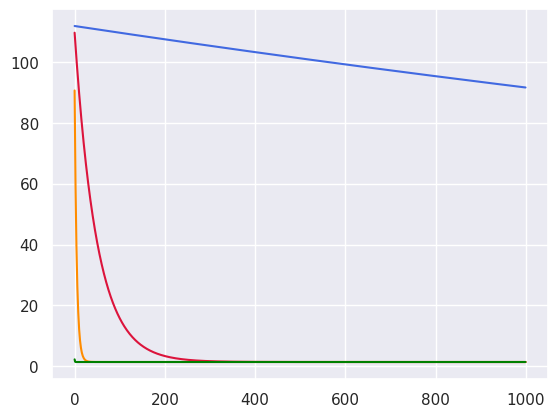

In [63]:
plt.plot(iter_list, cost_memo_1, color='royalblue')
plt.plot(iter_list, cost_memo_2, color='crimson')
plt.plot(iter_list, cost_memo_3, color='darkorange')
plt.plot(iter_list, cost_memo_4, color = 'green')
plt.show()

0.0001 value so small that is slow converge

1 is perfect


Q8. কেন Visualization কঠিন — practically দেখাও California Housing dataset এর যেকোনো ২টি feature নাও।

matplotlib এর plot_surface দিয়ে ২ feature → target এর 3D regression plane visualize করো

এরপর ৩টি feature দিয়ে model train করো এবং same ভাবে visualize করার চেষ্টা করো

কোড সহ explain করো ঠিক কোন জায়গায় visualization আর possible না এবং কেন


In [64]:
california = fetch_california_housing(as_frame=True)
df = california.frame
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [65]:
features = ['MedInc', 'HouseAge']
X = df[features]
y = df['MedHouseVal']

In [66]:
model = LinearRegression()
model.fit(X,y)

LinearRegression()

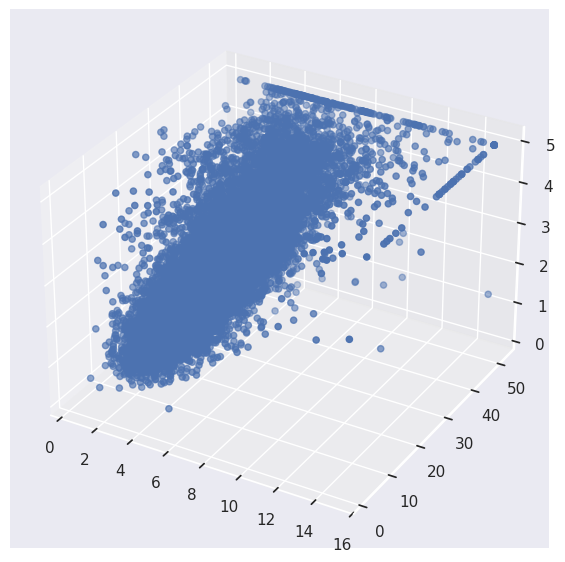

In [67]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['MedInc'], df['HouseAge'], y)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


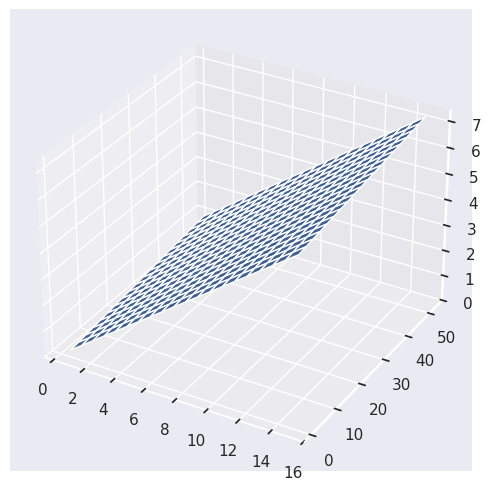

In [68]:
x_min, x_max = df['MedInc'].min(), df['MedInc'].max()
y_min, y_max = df['HouseAge'].min(), df['HouseAge'].max()

xs = np.linspace(x_min, x_max, 20)
ys = np.linspace(y_min, y_max, 20)

x_mesh, y_mesh = np.meshgrid(xs, ys)

grid_points = np.c_[x_mesh.ravel(), y_mesh.ravel()]

z_mesh = model.predict(grid_points).reshape(x_mesh.shape)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(x_mesh, y_mesh, z_mesh)
plt.show()

Q9. Real-world End-to-End Project Melbourne Housing dataset (Kaggle) নাও।

Relevant numeric features বেছে নাও, missing values handle করো
Feature ও target এর relationship analyze করো (scatter + correlation)
NumPy দিয়ে Gradient Descent চালিয়ে model train করো
Sklearn দিয়েও train করো

দুটোর MSE compare করো এবং কোনো feature এর coefficient negative হলে real-world এ সেটার meaning explain করো


In [69]:
df = pd.read_csv('/content/melb_data.csv')
df

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.79960,144.99840,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.79690,144.99690,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Wheelers Hill,12 Strada Cr,4,h,1245000.0,S,Barry,26/08/2017,16.7,3150.0,...,2.0,2.0,652.0,NaN,1981.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392.0
13576,Williamstown,77 Merrett Dr,3,h,1031000.0,SP,Williams,26/08/2017,6.8,3016.0,...,2.0,2.0,333.0,133.0,1995.0,NaN,-37.85927,144.87904,Western Metropolitan,6380.0
13577,Williamstown,83 Power St,3,h,1170000.0,S,Raine,26/08/2017,6.8,3016.0,...,2.0,4.0,436.0,NaN,1997.0,NaN,-37.85274,144.88738,Western Metropolitan,6380.0
13578,Williamstown,96 Verdon St,4,h,2500000.0,PI,Sweeney,26/08/2017,6.8,3016.0,...,1.0,5.0,866.0,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0


In [70]:
df.isnull().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


In [71]:
df.shape

(13580, 21)

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

In [73]:
df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


In [74]:
df_clean = df.drop(columns = ['BuildingArea', 'YearBuilt'])

In [75]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  CouncilArea    12211 non-null  object 
 15  Lattitude      13580 non-null  float64
 16  Longtitude     13580 non-null  float64
 17  Regionname     13580 non-null  object 
 18  Proper

In [76]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [77]:
numeric_features = ['Car', 'Rooms', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Landsize', 'Lattitude', 'Longtitude', 'Propertycount']
X = df_clean[numeric_features]
y = df_clean['Price'].values

In [78]:
train_analysis_df = pd.DataFrame(X, columns = numeric_features)
train_analysis_df['Price'] = y

<Axes: >

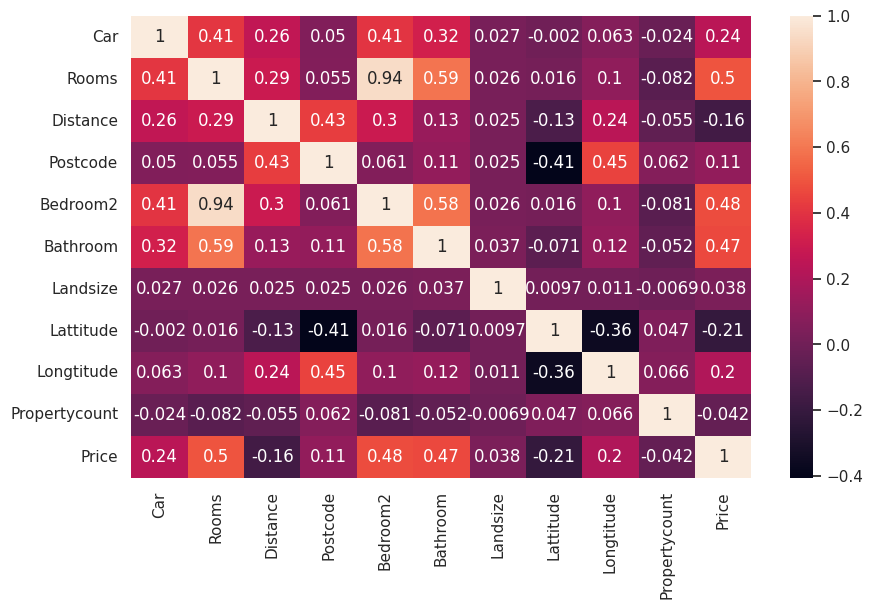

In [79]:
plt.figure(figsize=(10, 6))
sns.heatmap(train_analysis_df.corr(), annot = True)

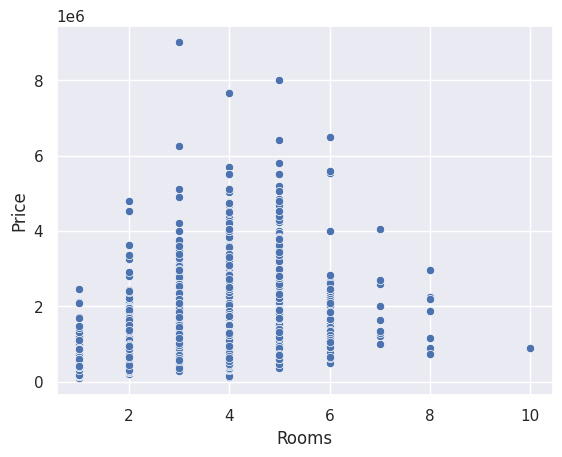

In [80]:
sns.scatterplot(data = df_clean, x = 'Rooms', y = 'Price')
plt.show()

In [81]:
from sklearn.model_selection import train_test_split

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [83]:
imputer_transformer = ColumnTransformer(
    transformers=[
        ('car',SimpleImputer(missing_values=np.nan , strategy='median'),['Car'])
    ],
    remainder='passthrough',
    verbose_feature_names_out = False
)
imputer_transformer.set_output(transform='pandas')

imputer_transformer.fit(X_train)

X_train = imputer_transformer.transform(X_train)
X_test = imputer_transformer.transform(X_test)

In [84]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [85]:
n = X_train.shape[1] # Recalculate n based on the new X
W_init = np.zeros((n,))
b_init = 0.0

w_final, b_final, cost_memo, iter_list = gradient_descent(X_train, y_train, w_input=W_init, b_input=b_init, max_iter=1000, alpha=0.01)

Iteration 0: Cost 768558115839.3334,dj_dw: [-147049.52017709 -317193.88951721  104026.64600908  -65931.77342848
 -302500.67297623 -296825.87394472  -30548.54055088  134611.54531481
 -130271.28934211   29270.12022008] ,dj_db : -1074964.92820324 w: [ 1470.49520177  3171.93889517 -1040.26646009   659.31773428
  3025.00672976  2968.25873945   305.48540551 -1346.11545315
  1302.71289342  -292.7012022 ], b: 10749.6493
Iteration 100: Cost 194247230014.1780,dj_dw: [ -2266.59629035 -38177.57830207 106617.45820803 -12052.27557445
 -25548.53339979 -32654.79615167  -5235.39686996  39520.9033518
 -25162.67802488   1010.98415183] ,dj_db : -393471.9294568395 w: [  40676.5254205   121946.18652529 -127828.95814778   24350.5958513
  108365.51892066  116438.26312829   11498.24042513  -75089.8607797
   59484.92936953   -8418.92389428], b: 685427.7180
Iteration 200: Cost 120270071334.3528,dj_dw: [ -1354.69121619 -15920.84114078  53779.25457938 -12855.04474566
  -4185.55225747  -2675.49505514  -4192.9593305

In [86]:
y_pred = make_prediction(X_test, w_final, b_final)
print(y_pred)

[1415649.06570084  955220.72450564 1231844.46398751 ... 1800045.38205965
 2453540.259629    950527.19194106]


In [87]:
mean_s_error = mean_squared_error(y_test, y_pred)
print(mean_s_error)

205291798789.70328


In [88]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [89]:
sk_y_pred = model.predict(X_test)
print(sk_y_pred)

[1414121.89733642  953504.45328335 1235215.78468517 ... 1867238.6140077
 2454703.22080588  950795.55987979]


In [90]:
sk_mean_s_error = mean_squared_error(y_test, sk_y_pred)
print(sk_mean_s_error)

205137269763.0567


ধরি, মডেল রান করার পর আপনার Distance (শহরের কেন্দ্র বা CBD থেকে দূরত্ব) ফিচারের কোইফিসিয়েন্ট এসেছে Negative (যেমন: -25,000)।বাস্তব অর্থ (Real-world meaning): বাড়ির অন্যান্য সমস্ত বৈশিষ্ট্য (যেমন- রুমের সংখ্যা, বাথরুমের সংখ্যা, ল্যান্ডসাইজ ইত্যাদি) যদি অপরিবর্তিত বা স্থির থাকে, তবে শহরের মূল কেন্দ্র বা CBD থেকে দূরত্ব প্রতি ১ ইউনিট বাড়লে বাড়ির দাম গড়ে প্রায় $25,000 কমে যাবে।কেন এমন হয়? রিয়েল-এস্টেট মার্কেটে শহরের মূল কেন্দ্রের কাছাকাছি যোগাযোগ ব্যবস্থা উন্নত হওয়ায় এবং সুযোগ-সুবিধা বেশি থাকায় মানুষ বেশি দামে বাড়ি কেনে। কেন্দ্র থেকে যত দূরে যাওয়া যায়, জমির বা বাড়ির চাহিদা জেনারেলি তত কমতে থাকে, যা নেগেটিভ কোইফিসিয়েন্ট দ্বারা প্রকাশ পায়।